# Deteccion de misoginia.

## Introducción

**Misoginia** :

    f. Aversión contra las mujeres.

**Machismo**

    m. Actitud de prepotencia de los varones respecto de las mujeres.

    m. Forma de discriminación sexista caracterizada por la prevalencia del varón. 

El discurso de odio hacia las mujeres representa una problemática social relevante. Debido a la relativia anonimidad de los entornos digitales, es en estos dónde el fenómeno se presenta con singular virulencia. Entre el espectro de las expresiones de odio se encuentran, desde las burlas, hasta explícitas incitaciones a la violencia. La detección del contenido violento y/o misógino representa un desafío de moderación considerable por el simple hecho del volúmen de datos que nos inundan todos los días. Identificar, clasificar y catalogar la violencia/misogínia es sin duda el primer paso para afrontar la problemática generada por la misma. 

Existe una amplia literatura al respecto del uso de sistemas de aprendizaje de máquina para identificar violencia en textos en inglés. Sin embargo, en el caso del español, existen ciertas limitantes que incrementan la dificultad del problema por lo que los esfuerzos que existen al respecto son limitados, comparados con el inglés. Un reto considerable es el hecho de que la naturaleza del lenguaje misógino se encuentra esparcida entre dos extremos, por un lado expresiones específicas y por otro, ímplicitas. Estas ultimas pueden observarse en formas que pueden ser irónicas o sarcásticas. Por si fuera poco, el significado en español algunas veces es relativo al pais o dialecto donde se origión la expresión. No es lo mismo el español latinoamericano argentino contra el colombiano o ibérico, por poner un ejemplo. 

El presente trabajo tiene como fin proponer un sistema de clasificación automática basado en algoritmos de aprendizaje de máquina para identificar discurso de odio hacia las mujeres. Uno de los reqquerimientos es generar un sistema que balancee la precisión con la exhaustividad. Una moderación estricta, si no es precisa, puede generar censura injustificada, un sistema de clasificación muy conservador puede permitir la circulación de discurso violento. El objetivo deseado es producir un sistema que optimize la precisión sin sacrificar la capacidad de detección.

En ese contexto, este reporte de investigación aborda la construcción y evaluación de sistemas de clasificación binaria de misoginia para textos cortos en español. Se discutirán a detalle técnicas de procesamiento de lenguaje natural para el diseño de los mismos, usando diversas técnicas de limpieza, preprocesamiento y análisis con el objetivo final de determinar un sistema que tenga el mejor desempeño. Este ultimo siendo definido, nuevamente, a partir de un sistema que optimize la precisión sin sacrificar la exhaustividad. 


## Base de Datos. 

Uno de los retos más significativos para emprender esta tarea es la recopilación de una base de datos que abarque las sutilezas, variantes y diversas connotaciones que caracterizan al idioma español. Como se mencionó anteriormente, el argot, el sarcasmo, las expresiones coloquiales típicas de dialectos regionales así como las variantes inherentes a un lenguaje tan extendido representan algunas de las dificultades. Afortunadamente, ya han existido esfuerzos, sobre todo de investigadores españoles, para consolidar observaciones que permitan entrenar sistemas de clasificación automática, entre los que destacan:

* La base de datos de AMI-Ibereval. 

* La base de datos de Misocorpus 2020. 

* Corpus RNN. 

La base de datos sobre la que se realizó el presente trabajo se construyó a partir del MisoCorpus2020 y del Corpus RNN.

### Origen de los datos. 

#### MisoCorpus2020

El misocorpus consiste de 7682 *tweets* (mensajes cortos de texto pertenecientes a la red social X) que fueron etiquetados como misóginos/no misóginos por un panel de expertos. Vale la pena mencionar que el consenso al respecto no siempre es unánime, lo cual demuestra la complejidad de la tarea de clasificación, así como confirma los comentarios al respecto de su dificultad mencionados en la sección anterior. 

El corpus esta dividido en 3 subconjuntos:

* VARW. El cual recopila tweets misóginos dirigidos hacia mujeres específicas de la esfera pública. (Celebridades de múltiples ámbitos).
* SELA. El cual recopila tweets misóginos/no misóginos de diversas regiones de latinoamérica y españa.
* DDDS. El cual recopila tweets misóginos/no misóginos que demuestren específicamente descrédito, dominancia, abuso sexual o estereotipos.
 
Dada la naturaleza de estos subconjuntos, se espera que el sistema de clasificación a desarrollar pueda analizar la misogínia a partir de, respectivamente, un contexto social, variaciones de dialectos regionales y abusos específicos.

#### Corpus RNN 

El corpusRNN fue desarrollado con un enfoque particular hacia el español latinoamericano, a partir de modelos de lenguaje y generadores de datos. 

Este corpus se constituye de:

* Una compilación de canciones misóginas seleccionadas manualmente.
* Refranes y expresiones populares latinoamericanas.
* Texto sintético generado mediante modelos de redes neuronales recurrentes. (RNN)
* La recopilación de textos aleatorios en español mediante un rastreador web que fue inicializado con palabras misóginas clave.

La diversidad de estas fuentes permite que el corpus incorpore expresiones explícitas e implícitas de la misoginia, que abarquen aspectos importantes como expresiones de lenguaje irónico/sarcástico o condicionadas a cierto contexto.

#### Consolidación

Juntos, ambos corpus incorporan datos que representan las siguientes ventajas:

* contexto social.
* variaciones del lenguaje de acuerdo a región.
* Variantes específicas de misogínia.
* contexto cultural.

Sin embargo, vale la pena mencionar que la base datos consolidada también tiene ciertas desventajas.

* Posible sesgo en la recolección. 
* Subjetividad en la anotación.


La misoginia, lamentablemente, se puede presentar tanto explícita como implícitamente, a veces incluso disfrazada de expresiones neutras y/o humorísticas. Es por ello que se determinó que un corpus nutrido de diversas fuentes, aún con las limitantes mencionadas anteriormente, constituye un buen punto de partida para un sistema de clasificación automática. 


## Análisis Exploratorio de la Base de Datos. 

### Descripción general de la base. 

La base de datos consiste de 11,114 textos cortos en español. La mayoría de ellos **tweets** de la red social X, todos etiquetados como violento/no violento con respecto a la misoginia. 

Es importante recalcar que la cantidad de textos violentos sobrepasa la de los no violentos casi en una proporción de 3 a 1. Específicamente, hay 8102 observaciones violentas vs 3012 observaciones no violentas. Este desbalance no puede pasar desapercibido ya que debe ser considerado a la hora de diseñar y evaluar los sistemas de clasificación, así como también en la calibración de los umbrales del sistema de producción.

### Longitud de los textos. 

En la figura 1 se observa la distribución de la cantidad de palabras por cada texto en la base de datos. 


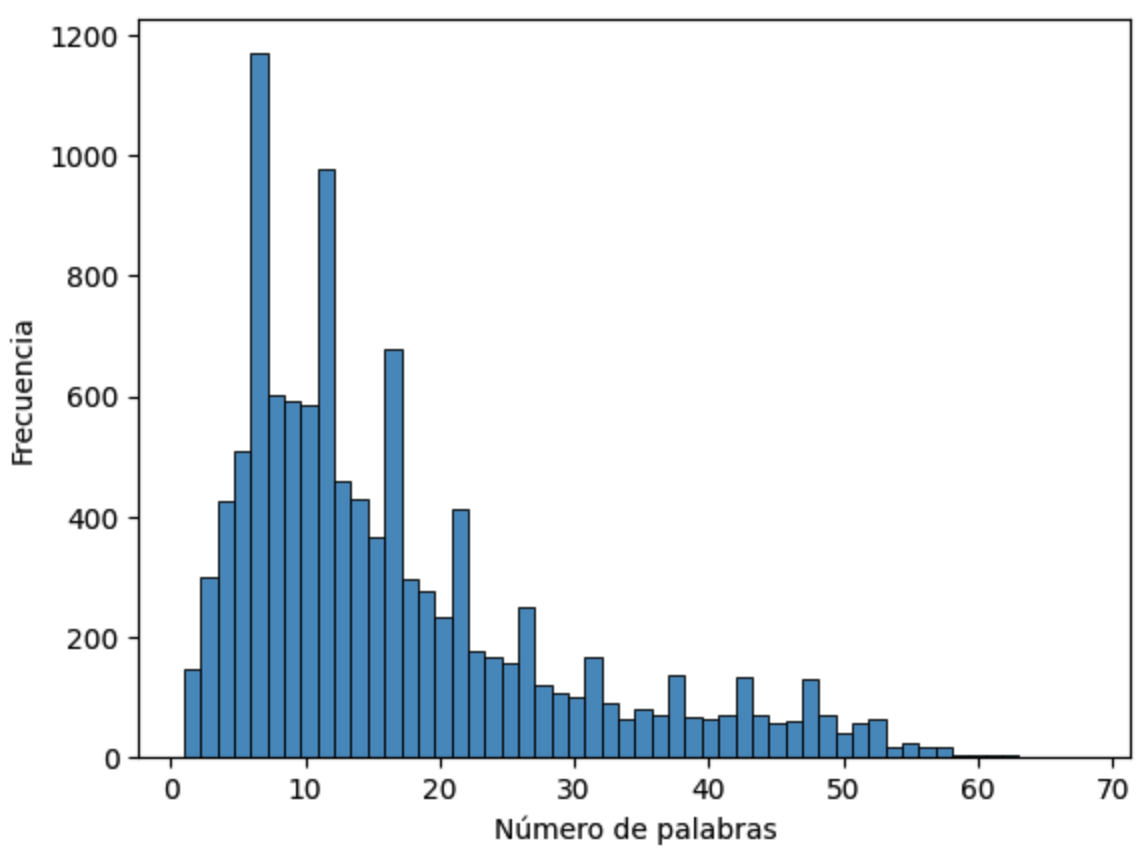

En la figura 2 se observa que la longitud de los textos es prácticamente irrelevante para clasificarlos como misógino/no misógino, ya que presentan distribuciones muy similares. 

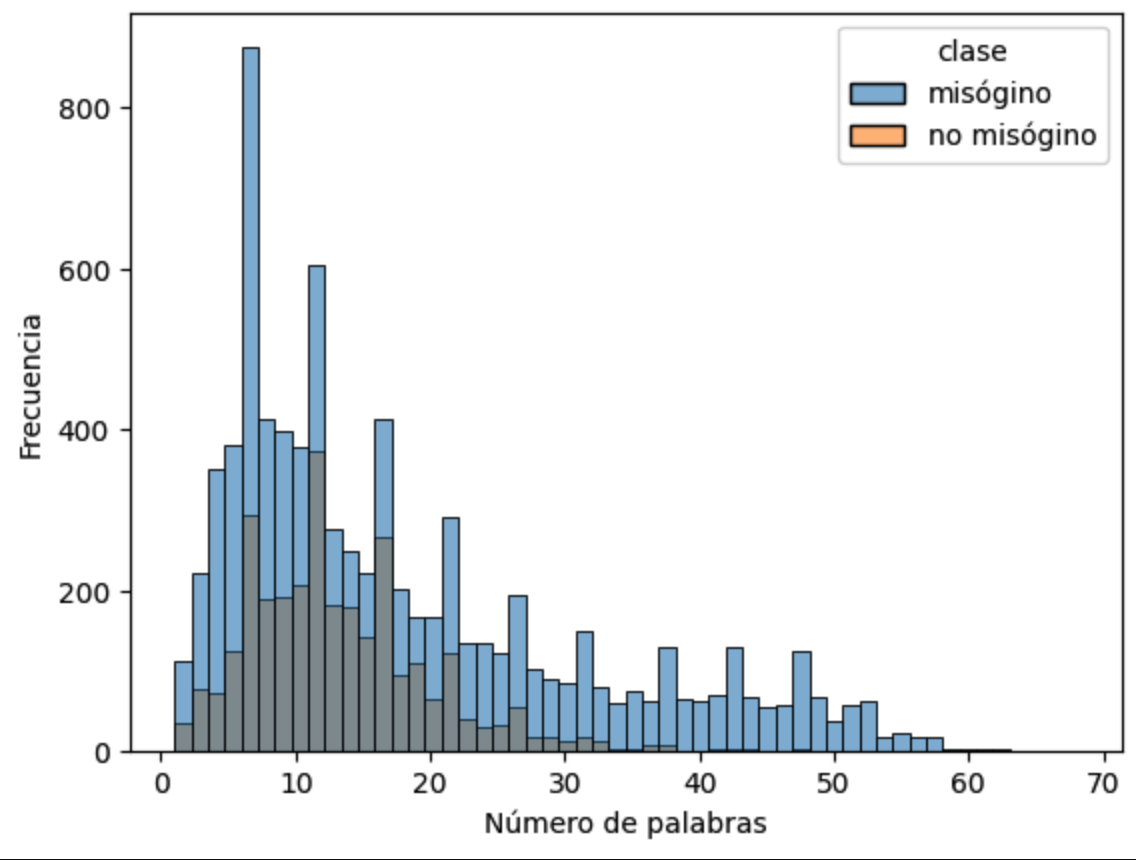

### Análisis léxico.

Se realizó un análisis de frecuencia de palabras por clase violenta/no violenta. Como puede verse en las figuras 3 y 4, los textos violentos cuentan con una alta frecuencia de términos en español explícitamente agresivos/degradantes contra la mujer. Por otro lado, los textos no violentos presentan una terminología mucho más neutral, ambigua. Esta característica de la base de datos sugiere que hay una varianza/diferencia léxica clara (palabras muy distintas entre clases) que modelos de clasificación pueden potencialmente detectar. No obstante, vale la pena mencionar que también existe vocabulario en común (la palabra **mujer** es un claro ejemplo) que sugieren una varianza semántica. Por decirlo simplemente, las palabras encierran un patrón de diferenciamiento, efectivamente, pero también el contexto.




In [ ]:
En la figura 3 se observan las palabras mas frecuentes en los textos misóginos.

In [ ]:
En la figura 4 se observan las pablabras más frecuentes en los textos no misóginos. 

#### Solapamiento léxico entre clases.

Cuantificar el solapamiento de palabras entre clases puede darnos una medida explícita de lo mencionado anteriormente. Para estos casos se suele utilizar el coeficiente de Jaccard. 

Dados dos conjuntos de palabras A y B, el coeficiente de Jaccard se calcula como el cociente del numero de elementos de la intersección de los conjuntos A y B, y el número de elementos de la unión de A y B. 

Por ejemplo, si A y B tienen las mismas palabras, el coeficiente será 1, y si no tienen ninguna palabra en común, el coeficiente será 0.

FORMULA DE JACCARD AQUI. 


Vocabulario violento: 14729
Vocabulario no violento: 5631
Palabras compartidas: 3202

El coeficiente de similitud de Jaccard entre los textos violentos y no violentos es de .18 


Existe un conjunto significativo de palabras distintivas asociadas a los textos violentos, por lo que muchos términos por si mismos pueden ayudar a identificar
contenido violento/ no violento. Sin embargo también existen 3202 palabras que se solapan, lo cual aunado a un coeficiente de Jaccard de .18,
este valor sugiere que existe un conjunto considerable (3202) de palabras compartidas entre ambos tipos de textos lo cual puede
sugerir que los sistemas de clasificación que tomen en cuenta diferencias léxicas y semánticas pueden tener un mejor desempeñó que aquellos que solo tomen
en cuenta las diferentes palabras entre los textos. 


### Palabras discriminativas. 

NOTA: Conectar con los coeficientes de regresión logística después y comparar. 

A continuación, para identificar términos representativos de cada tipo de texto, se calculó el logaritmo del cociente de frecuencias entre palabras de ambos textos. 

log-odds(w) = log₂((f_v(w) + 1) / (f_nv(w) + 1))

f_v es la frecuencia de la palabra w en la clase violenta.
f_nv es la frecuencia de la palabra w en la clase no violenta. 

el +1 corresponde a una constante de suavizamiento que evita la división entre 0 para palabras que no existen en los textos no violentos. 

Si comparamos el cociente, sabemos que un valor > 1 corresponde a palabras que aparecen mas en la clase violenta, y < 1 palabras que aparecen más en la case no violenta. 
Sin embargo, el valor del cociente no es muy comparable visualmente entre palabras en términos de magnitudes, por lo que una vez que aplicamos el logaritmo base 2, obtenemos simetría. 

Ejemplo:

Tomemos dos palabras, A y B. 

 A aparece en 99 textos violentos, y en 9 textos no violentos. 
 B aparecen en 99 textos no violentos y en 9 textos violentos.


Para una palabra A: 100/10 = 10

Para una palabra B: 10/100 = .1

Si aplicamos el logaritmo base 2:

Para una palabra A: log2(10) = + 3.32

Para una palabra B: log2(.1) = - 3.32

Por lo tanto , para valores > 0 la palabra w aparece más en la clase violenta. En correspondencia, para valores < 0 la palabra w aparece más en la clase no violenta. Esta métrica nos permite comparar palabras entre sí y detectar aquellas que son representativas de cada clase. 


En la figura BLABLAB se puede apreciar que los textos violentos, como se mencionó anteriormente, tienen como términos dominantes palabrás violentas y explícitas, contrario a los términos de la clase no misógina. Nuevamente se sospecha que las señales léxicas son la mejor forma de diferenciación, sin dejar de lado, en menor forma, las señales semánticas asociadas muchas veces a contenido implícito. 



### Análisis de n-gramas. 

Con respecto al contenido semántico de los textos se realizó un análisis de bigramas y trigramas para detectar la frecuencia de patrones compuestos, así como la posible evidencia de señal semántica. 

Como se observa en las tablas BLABLA, la presencia de palabras explícitas no necesariamente indica violencia, el contexto es necesario para determinarlo, y este se puede inferir a partir de las combinaciones de palabras. Esto señala que un sistema de clasificación precisio necesita capturar la señal relacionada a estas combinaciones, no puede reducirse al significado y/o presencia de palabras individuales. 

### Representaciones visuales.

A continuación se presentan las nubes de palabras asociadas a cada clase. Estas representaciones permiten observar la predominancia de ciertos términos en cada clase, asi como en la base de datos. 


El análisis exploratorio claramente demuestra señales léxicas importantes en la base de datos, específicamente en la clase misógina. Sin embargo, también hay que recalcar que existe un importante conjunto de vocabulario compartido entre clases, lo que justifica la necesidad de incorporar preprocesamiento que capture también la señal semántica, contextual y no sólo la que corresponde a vocabulario. El fenómeno como bien lo sugiere la introducción, abarca contenido explícito así como implícito, por lo que es importante capturar la señal de ambos. 